4096
4096
Изображение сохранено в maze_output.png


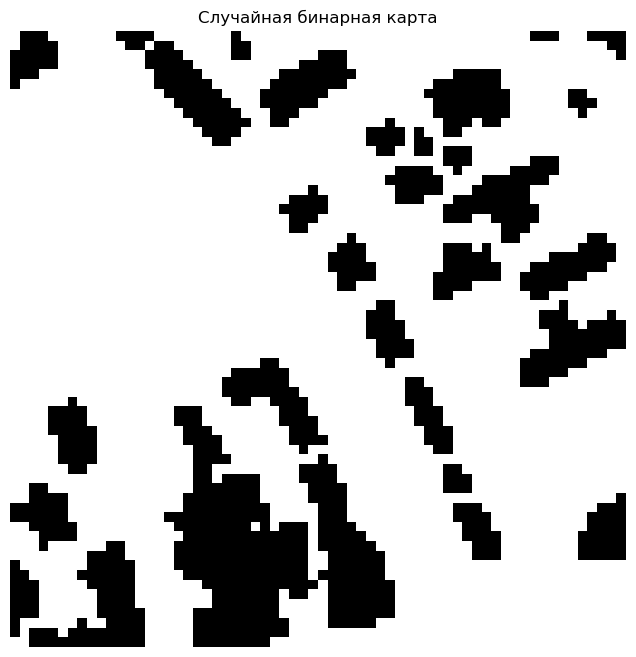

In [13]:
import numpy as np
import os
import glob
from PIL import Image
from skimage.filters import threshold_otsu
import random
import matplotlib.pyplot as plt

def generate_single_binary_maze(input_dir, output_size=64):
    """
    Генерирует одну бинарную карту размера output_size x output_size.
    
    Функция выбирает случайное изображение из директории, вырезает из него фрагмент,
    затем преобразует его в бинарную карту с помощью порогового значения.
    
    Args:
        input_dir (str): путь к директории с исходными изображениями .png
        output_size (int): размер выходной матрицы (по умолчанию 64x64)
        
    Returns:
        np.ndarray: бинарная матрица размера output_size x output_size
    """
    # Ищем все подходящие файлы
    image_files = glob.glob(os.path.join(input_dir, "*_256.png"))
    
    if not image_files:
        raise FileNotFoundError(f"В директории {input_dir} не найдено файлов с шаблоном *_256.png")
    
    # Выбираем случайный файл
    random_file = random.choice(image_files)
    
    # Открываем и преобразуем в полутоновое изображение
    img = Image.open(random_file).convert("L").resize((256, 256))
    
    # Задаем размер вырезаемого фрагмента
    crop_size = 128
    
    # Генерируем случайную координату для левого верхнего угла фрагмента
    left = np.random.randint(0, 256 - crop_size)
    top = np.random.randint(0, 256 - crop_size)
    
    # Вырезаем фрагмент
    cropped = img.crop((left, top, left + crop_size, top + crop_size))
    
    # Изменяем размер фрагмента до требуемого
    resized = cropped.resize((output_size, output_size))
    
    # Преобразуем в массив numpy
    image_array = np.asarray(resized, dtype=np.float32)
    
    # Применяем пороговое значение для получения бинарной карты
    threshold = threshold_otsu(image_array)
    binary_map = np.zeros_like(image_array)
    binary_map[image_array > threshold] = 1.0
    
    return binary_map.astype(np.uint8)


def plot_binary_maze(maze, title="Бинарная карта", save_path=None):
    """
    Визуализирует бинарную карту с помощью matplotlib.
    
    Args:
        maze (np.ndarray): бинарная матрица для визуализации
        title (str): заголовок графика
        save_path (str, optional): путь для сохранения изображения, если None - только отображает
    """
    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap='gray', interpolation='nearest')
    plt.title(title)
    plt.axis('off')  # Убираем оси
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Изображение сохранено в {save_path}")
    
    plt.show()

# Пример использования:
maze = generate_single_binary_maze("/home/silvarum/planning-datasets/data/street/original/all", 64)
print((maze == 1).sum() + (maze == 0).sum())
print(64 * 64)
plot_binary_maze(maze, "Случайная бинарная карта", "maze_output.png")

In [98]:
print(plt.colormaps())  # Для версий Matplotlib 3.4 и выше

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't


Карта 2: Клеточный автомат


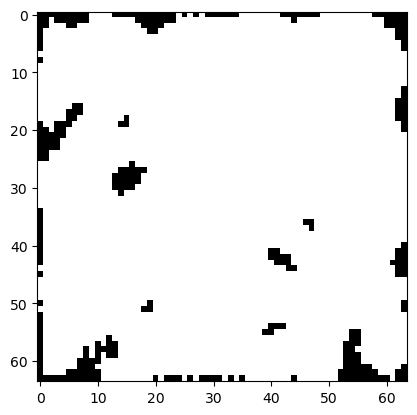

In [5]:
import random

def generate_cellular_automata_map():
    # Начальная генерация
    grid = [[1 if np.random.uniform() < 0.45 else 0 for _ in range(64)] for _ in range(64)]
    
    def count_neighbors(i, j, grid):
        count = 0
        for di in (-1, 0, 1):
            for dj in (-1, 0, 1):
                if di == 0 and dj == 0:
                    continue
                ni, nj = i + di, j + dj
                if 0 <= ni < 64 and 0 <= nj < 64:
                    count += grid[ni][nj]
                else:
                    # За границей считаем ячейку заполненной
                    count += 1
        return count
    
    # Применяем правило несколько раз (например, 4 итерации)
    for _ in range(4):
        new_grid = [[0]*64 for _ in range(64)]
        for i in range(64):
            for j in range(64):
                if count_neighbors(i, j, grid) >= 5:
                    new_grid[i][j] = 1
                else:
                    new_grid[i][j] = 0
        grid = new_grid
    return 1-np.array(grid)

# Вывод карты:
print("\nКарта 2: Клеточный автомат")
plt.imshow(generate_cellular_automata_map(), cmap='gray')
plt.show()


Карта 3: Круговая структура


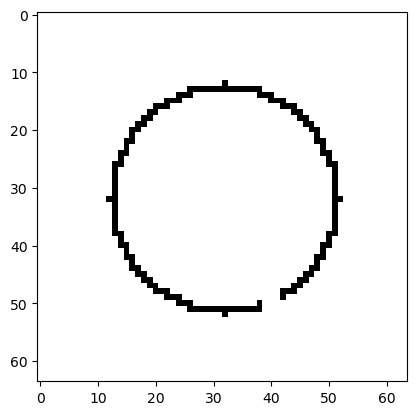

In [23]:
def generate_circular_map():
    center = 32
    radius_sq = 400  # 20^2
    grid = []
    for i in range(64):
        row = []
        for j in range(64):
            if (i - center)**2 + (j - center)**2 <= radius_sq:
                row.append(1)
            else:
                row.append(0)
        grid.append(row)
    bound_coords = []
    for i in range(64):
        for j in range(64):
            if (i - center)**2 + (j - center)**2 <= radius_sq - 48:
                grid[i][j] = 0
            elif grid[i][j] == 1:
                bound_coords.append((i, j))
    intro = bound_coords[np.random.choice(len(bound_coords))]
    for i in range(-1, 2):
        for j in range(-1, 2):
            grid[intro[0] + i][intro[1] + j] = 0
    return 1 - np.array(grid)

# Вывод карты:
print("\nКарта 3: Круговая структура")
plt.imshow(generate_circular_map(), cmap='gray')
plt.show()

Карта 4: Спираль


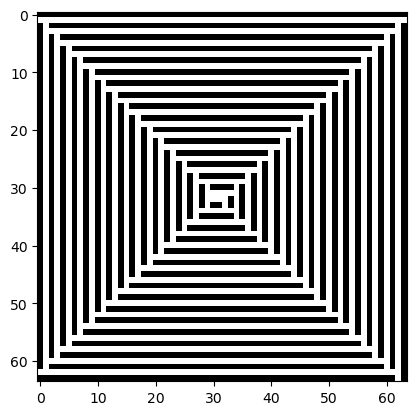

In [8]:
def generate_spiral_map():
    N = 64
    grid = [[0 for _ in range(N)] for _ in range(N)]
    top, bottom = 0, N - 1
    left, right = 0, N - 1
    direction = 0
    step = 2
    while top <= bottom and left <= right:
        if direction == 0:
            for j in range(left, right + 1):
                grid[top][j] = 1
            top += step
        elif direction == 1:
            for i in range(top, bottom + 1):
                grid[i][right] = 1
            right -= step
        elif direction == 2:
            for j in range(right, left - 1, -1):
                grid[bottom][j] = 1
            bottom -= step
        elif direction == 3:
            for i in range(bottom, top - 1, -1):
                grid[i][left] = 1
            left += step
        direction = (direction + 1) % 4
    return 1 - np.array(grid)

# Вывод карты:
print("Карта 4: Спираль")
plt.imshow(generate_spiral_map(), cmap='gray')
plt.show()



Карта 5: Симметричная карта


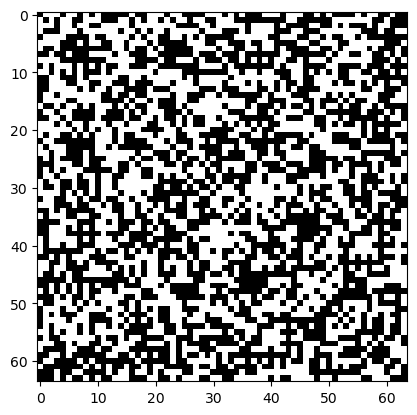

In [5]:
import random

def generate_symmetric_map():
    random.seed(0)
    grid = [[0 for _ in range(64)] for _ in range(64)]
    for i in range(64):
        for j in range(i, 64):
            val = np.random.choice([0, 1])
            grid[i][j] = val
            grid[j][i] = val
    return 1 - np.array(grid)

# Вывод карты:
print("\nКарта 5: Симметричная карта")
plt.imshow(generate_symmetric_map(), cmap='gray')
plt.show()



Карта 6: Шахматная доска


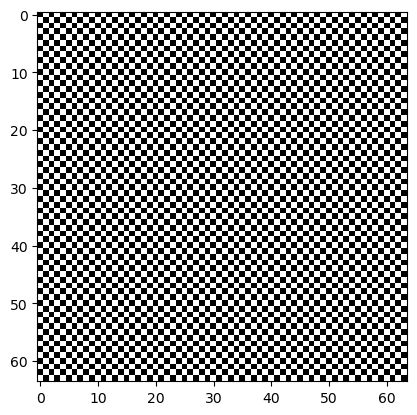

In [6]:
def generate_checkerboard_map():
    grid = []
    for i in range(64):
        row = []
        for j in range(64):
            if (i + j) % 2 == 0:
                row.append(1)
            else:
                row.append(0)
        grid.append(row)
    return 1 - np.array(grid)

# Вывод карты:
print("\nКарта 6: Шахматная доска")
plt.imshow(generate_checkerboard_map(), cmap='gray')
plt.show()



Карта 10: Волновые интерференции


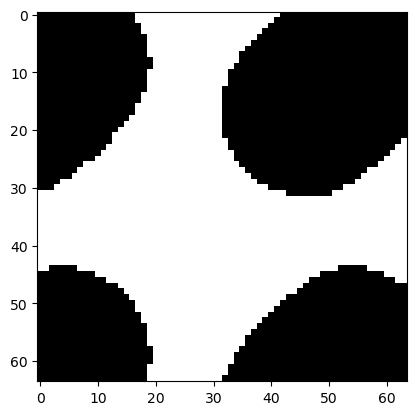

In [60]:
import math

def generate_wave_interference_map():
    grid = []
    for i in range(64):
        row = []
        for j in range(64):
            # Комбинируем несколько волн с различными параметрами
            value = math.sin(i / 8.0) + math.cos(j / 8.0) + 0.5 * math.sin((i + j) / 8.0)
            row.append(1 if value > 0 else 0)
        grid.append(row)
    return 1 - np.array(grid)

print("\nКарта 10: Волновые интерференции")
plt.imshow(generate_wave_interference_map(), cmap='gray')
plt.show()


Карта 11: Квадратные узоры


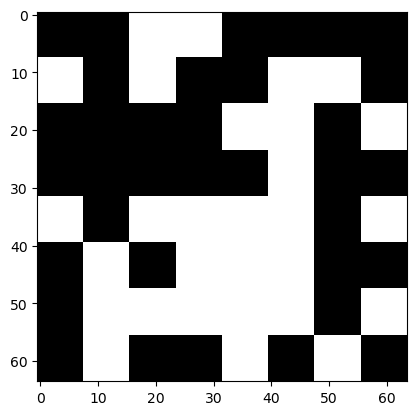

In [72]:
import random

def generate_block_pattern_map():
    grid = [[0] * 64 for _ in range(64)]
    block_size = 8
    for bi in range(0, 64, block_size):
        for bj in range(0, 64, block_size):
            block_val = random.choice([0, 1])
            for i in range(bi, bi + block_size):
                for j in range(bj, bj + block_size):
                    grid[i][j] = block_val
    return 1 - np.array(grid)

print("\nКарта 11: Квадратные узоры")
plt.imshow(generate_block_pattern_map(), cmap='gray')
plt.show()

Карта 13: Альтернативные концентрические кольца


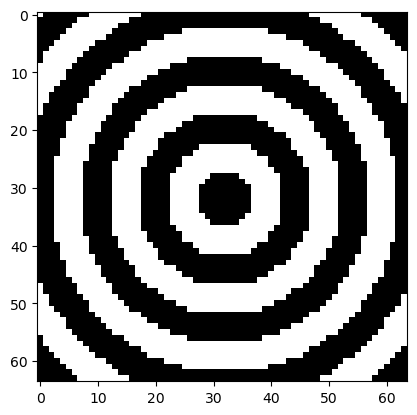

In [77]:
def generate_alternating_concentric_rings():
    center = 32
    ring_width = 5
    grid = []
    for i in range(64):
        row = []
        for j in range(64):
            distance = ((i - center)**2 + (j - center)**2) ** 0.5
            ring_index = int(distance // ring_width)
            row.append(1 if ring_index % 2 == 0 else 0)
        grid.append(row)
    return 1 - np.array(grid)

print("Карта 13: Альтернативные концентрические кольца")
plt.imshow(generate_alternating_concentric_rings(), cmap='gray')
plt.show()


Карта 15: Рекурсивное деление


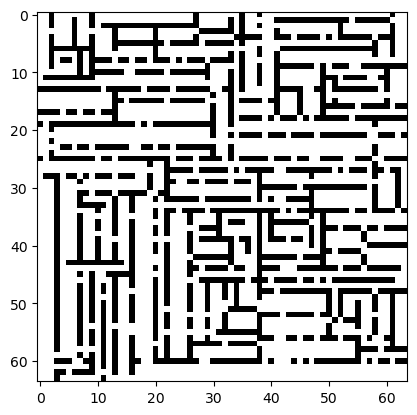

In [ ]:
import random

def generate_recursive_division_map():
    grid = [[0 for _ in range(64)] for _ in range(64)]
    
    def divide(x, y, w, h, orientation):
        if w < 4 or h < 4:
            return
        if orientation == 'H':
            split = random.randint(y+1, y+h-2)
            for j in range(x, x+w):
                grid[split][j] = np.random.choice([0, 1], p = [0.2, 0.8])
            divide(x, y, w, split-y, 'V')
            divide(x, split+1, w, y+h-split-1, 'V')
        else:  # вертикальное деление
            split = random.randint(x+1, x+w-2)
            for i in range(y, y+h):

                grid[i][split] = np.random.choice([0, 1], p = [0.2, 0.8])
            divide(x, y, split-x, h, 'H')
            divide(split+1, y, x+w-split-1, h, 'H')

    divide(0, 0, 64, 64, 'H')
    return 1 - np.array(grid)

print("\nКарта 15: Рекурсивное деление")
plt.imshow(generate_recursive_division_map(), cmap='gray')
plt.show()


Карта 21: Лабиринт с возвратами (DFS)


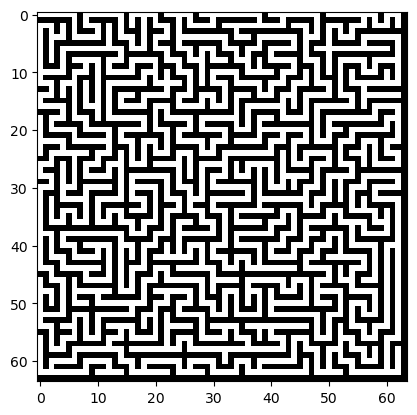

In [27]:
import random

def generate_maze_dfs():
    grid = [[1 for _ in range(64)] for _ in range(64)]
    start = (0, 0)
    stack = [start]
    grid[0][0] = 0
    directions = [(-2, 0), (2, 0), (0, -2), (0, 2)]
    
    def neighbors(cell):
        x, y = cell
        result = []
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if 0 <= nx < 64 and 0 <= ny < 64:
                result.append((nx, ny))
        return result
    
    while stack:
        current = stack[-1]
        unvisited = [n for n in neighbors(current) if grid[n[0]][n[1]] == 1]
        if unvisited:
            next_cell = random.choice(unvisited)
            # Прорезаем проход между current и next_cell
            mid = ((current[0] + next_cell[0]) // 2, (current[1] + next_cell[1]) // 2)
            grid[next_cell[0]][next_cell[1]] = 0
            grid[mid[0]][mid[1]] = 0
            stack.append(next_cell)
        else:
            stack.pop()
    return 1 - np.array(grid)

print("\nКарта 21: Лабиринт с возвратами (DFS)")
plt.imshow(generate_maze_dfs(), cmap='gray')
plt.show()



Карта 23: Случайные линии


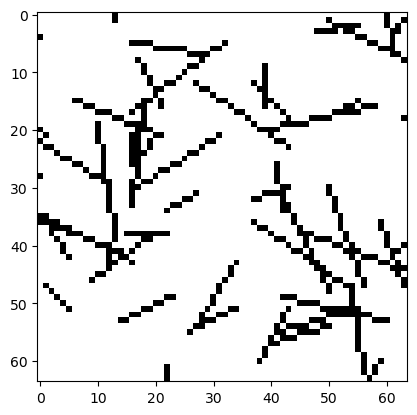

In [24]:
import random, math

def generate_random_lines_map():
    grid = [[0 for _ in range(64)] for _ in range(64)]
    
    def draw_line(x0, y0, x1, y1):
        dx = abs(x1 - x0)
        dy = abs(y1 - y0)
        sx = 1 if x0 < x1 else -1
        sy = 1 if y0 < y1 else -1
        err = dx - dy
        while True:
            if 0 <= x0 < 64 and 0 <= y0 < 64:
                grid[y0][x0] = 1
            if x0 == x1 and y0 == y1:
                break
            e2 = 2 * err
            if e2 > -dy:
                err -= dy
                x0 += sx
            if e2 < dx:
                err += dx
                y0 += sy
    
    # Рисуем, например, 50 случайных линий
    for _ in range(50):
        x0 = random.randint(0, 63)
        y0 = random.randint(0, 63)
        angle = random.uniform(0, 2 * math.pi)
        length = random.randint(5, 20)
        x1 = x0 + int(round(math.cos(angle) * length))
        y1 = y0 + int(round(math.sin(angle) * length))
        draw_line(x0, y0, x1, y1)
    
    return 1 - np.array(grid)

print("\nКарта 23: Случайные линии")
plt.imshow(generate_random_lines_map(), cmap='gray')
plt.show()



Карта 26: Нерегулярная решетка


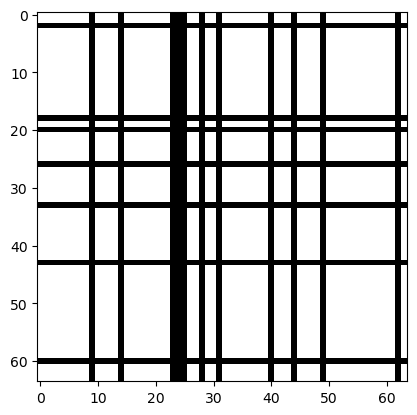

In [47]:
import random

def generate_irregular_grid():
    grid = [[0 for _ in range(64)] for _ in range(64)]
    # С вероятностью 10% выбираем строки для горизонтальных линий
    horizontal_lines = [i for i in range(64) if random.random() < 0.1]
    # С вероятностью 10% выбираем столбцы для вертикальных линий
    vertical_lines = [j for j in range(64) if random.random() < 0.1]
    
    for i in horizontal_lines:
        for j in range(64):
            grid[i][j] = 1
    for j in vertical_lines:
        for i in range(64):
            grid[i][j] = 1
    return 1 - np.array(grid)

print("\nКарта 26: Нерегулярная решетка")
plt.imshow(generate_irregular_grid(), cmap='gray')
plt.show()


Карта 30: Случайная текстура (Perlin Noise-подобная)


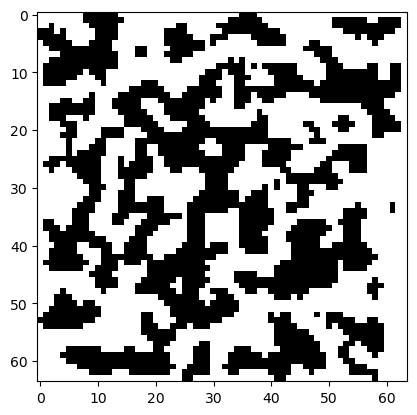

In [171]:
import random

def generate_random_texture():
    grid = [[random.randint(0, 1) for _ in range(64)] for _ in range(64)]

    # Применяем размытие: заменяем каждую ячейку на среднее её соседей
    for _ in range(2):  # Два прохода сглаживания
        new_grid = [[0 for _ in range(64)] for _ in range(64)]
        for i in range(64):
            for j in range(64):
                neighbors = [
                    grid[x][y] for x in range(max(0, i - 1), min(64, i + 2))
                               for y in range(max(0, j - 1), min(64, j + 2))
                ]
                new_grid[i][j] = 1 if sum(neighbors) > 4 else 0  # Усредняем
        grid = new_grid
    
    return 1 - np.array(grid)

print("\nКарта 30: Случайная текстура (Perlin Noise-подобная)")
plt.imshow(generate_random_texture(), cmap='gray')
plt.show()



Карта 42: Лабиринт по алгоритму Прима


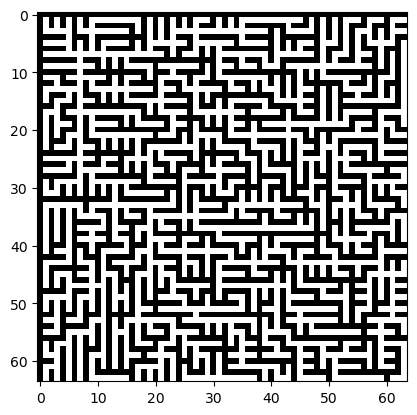

In [87]:
import random

def generate_maze_prim():
    width, height = 64, 64
    # Заполняем карту стенами (1)
    grid = [[1 for _ in range(width)] for _ in range(height)]
    # Матрица для отслеживания посещённых ячеек (только для ячеек с нечётными индексами)
    visited = [[False for _ in range(width)] for _ in range(height)]
    
    def add_walls(r, c, walls):
        for dr, dc in [(0,2), (2,0), (0,-2), (-2,0)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < height and 0 <= nc < width and not visited[nr][nc]:
                # Стена находится между (r,c) и (nr,nc)
                walls.append((r + dr//2, c + dc//2, nr, nc))
    
    # Выбираем случайную стартовую ячейку с нечётными индексами
    start_r = random.choice(range(1, height, 2))
    start_c = random.choice(range(1, width, 2))
    grid[start_r][start_c] = 0
    visited[start_r][start_c] = True
    walls = []
    add_walls(start_r, start_c, walls)
    
    while walls:
        idx = random.randrange(len(walls))
        wr, wc, nr, nc = walls.pop(idx)
        if not visited[nr][nc]:
            grid[wr][wc] = 0  # Удаляем стену
            grid[nr][nc] = 0  # Делаем клетку проходом
            visited[nr][nc] = True
            add_walls(nr, nc, walls)
    
    return 1 - np.array(grid)

print("\nКарта 42: Лабиринт по алгоритму Прима")
plt.imshow(generate_maze_prim(), cmap='gray')
plt.show()



Карта 44: Комбинированные квадранты


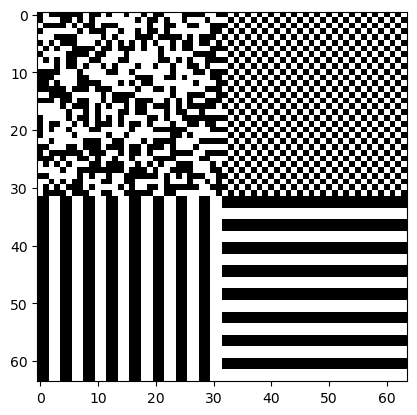

In [76]:
import random

def generate_quadrant_map():
    size = 64
    half = size // 2
    grid = [[0 for _ in range(size)] for _ in range(size)]
    
    # Верхний левый: случайный шум
    for i in range(half):
        for j in range(half):
            grid[i][j] = 1 if random.random() < 0.5 else 0
    
    # Верхний правый: шахматная доска
    for i in range(half):
        for j in range(half, size):
            grid[i][j] = 1 if ((i + j) % 2 == 0) else 0
    
    # Нижний левый: вертикальные полосы (каждый 4-й столбец чередуется)
    for i in range(half, size):
        for j in range(half):
            grid[i][j] = 1 if (j % 4 < 2) else 0
    
    # Нижний правый: горизонтальные полосы (каждая 4-я строка чередуется)
    for i in range(half, size):
        for j in range(half, size):
            grid[i][j] = 1 if ((i - half) % 4 < 2) else 0
    
    return 1 - np.array(grid)

print("\nКарта 44: Комбинированные квадранты")
plt.imshow(generate_quadrant_map(), cmap='gray')
plt.show()


In [1]:
import random

def generate_majority_filter_map(iterations=5):
    size = 64
    # Начальная случайная карта
    grid = [[1 if random.random() < 0.5 else 0 for _ in range(size)] for _ in range(size)]
    
    for _ in range(iterations):
        new_grid = [[0]*size for _ in range(size)]
        for i in range(size):
            for j in range(size):
                count = 0
                for di in (-1, 0, 1):
                    for dj in (-1, 0, 1):
                        ni, nj = i + di, j + dj
                        if 0 <= ni < size and 0 <= nj < size:
                            count += grid[ni][nj]
                # Если больше половины (из 9 ячеек) равны 1, ставим 1, иначе 0
                new_grid[i][j] = 1 if count > 4 else 0
        grid = new_grid
    return 1 - np.array(grid)

print("\nКарта 45: Итеративный фильтр большинства")
plt.imshow(generate_majority_filter_map(), cmap='gray')
plt.show()



Карта 45: Итеративный фильтр большинства


NameError: name 'plt' is not defined

Карта 52: Горизонтальный градиент паттернов


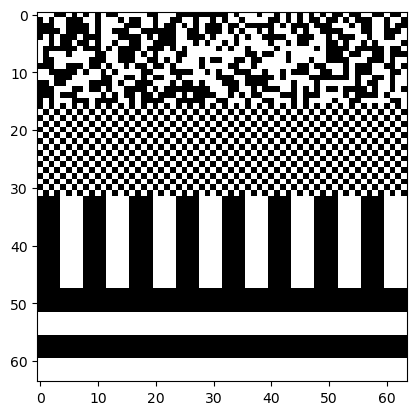

maze
pyramid
Perlin_noise
random_lines
recursive_division
rotational_symmery_maps
dcaffo_maps
house_expo_maps
moving_street_maps
baldurs_gate_maps
Директория '/home/silvarum/TransPath_Adaptation/results/dataset_images/tmp_maps' создана


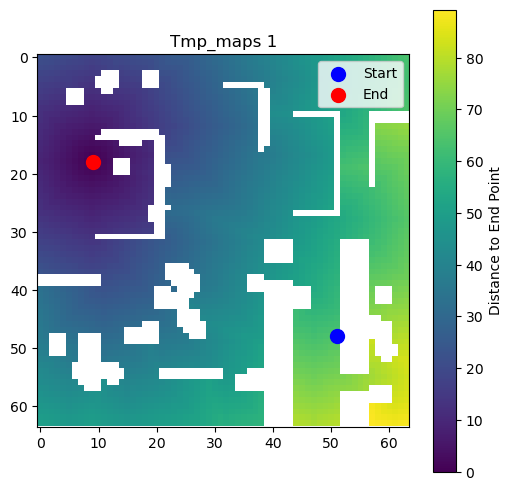

Директория '/home/silvarum/TransPath_Adaptation/results/dataset_images/tmp_maps' уже существует


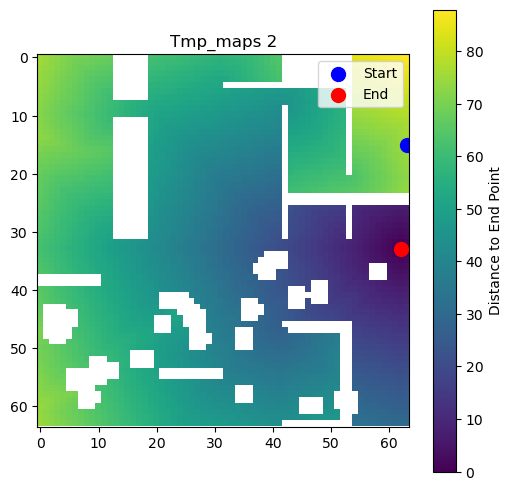

Директория '/home/silvarum/TransPath_Adaptation/results/dataset_images/tmp_maps' уже существует


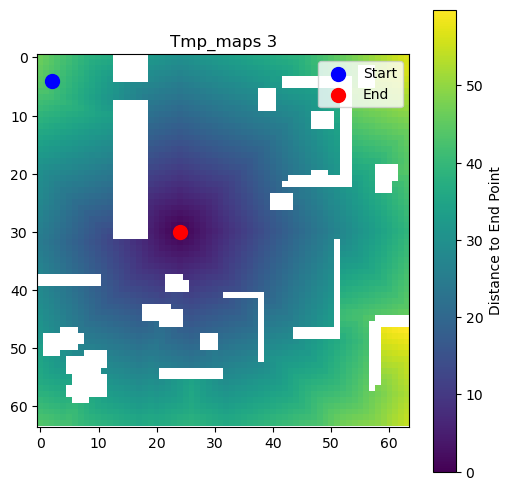

Директория '/home/silvarum/TransPath_Adaptation/results/dataset_images/tmp_maps' уже существует


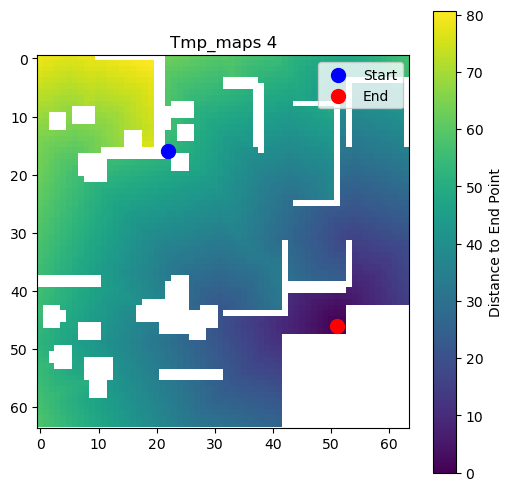

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os
import sys
sys.path.append('/home/silvarum/TransPath_Adaptation')  # Полный путь к корневой директории

def create_directory_if_not_exists(directory_path):
    """
    Проверяет существование директории и создает ее, если она не существует.
    
    Args:
        directory_path (str): Путь к директории
    """
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        print(f"Директория '{directory_path}' создана")
    else:
        print(f"Директория '{directory_path}' уже существует")


def plot_map(T, i, pattern, save_dir=None):
    """
    Визуализация {i}-ой карты с начальной и конечной точками, а также результатом Дейкстры с прозрачными областями вне карты.

    Параметры:
        T (np.ndarray): Тензор данных размером (N, 64, 64, 4).
        i (int): Индекс карты для отображения.
        save_path (str): Путь для сохранения изображения (если указан).
    """
    B = T[..., 1]
    C = T[..., 2]
    D = T[..., 3]

    # Копируем массив расстояний и заменяем нули на NaN для прозрачных областей
    distances = np.copy(C[i])
    distances[distances == 0] = np.nan

    # Создаем цветовую карту с прозрачным фоном
    cmap = plt.cm.viridis
    cmap.set_bad(color=(0, 0, 0, 0))  # Прозрачный цвет для NaN

    plt.figure(figsize=(6, 6), dpi=100)
    plt.title(f"{pattern} {i + 1}".capitalize())

    # Визуализация карты с прозрачным фоном для областей вне карты
    img = plt.imshow(distances, cmap=cmap, vmin=0, vmax=np.nanmax(distances))

    # Наносим начальную и конечную точки
    start_point = np.argwhere(D[i] == 1)
    end_point = np.argwhere(B[i] == 1)

    if len(start_point) > 0:
        plt.scatter(start_point[0, 1], start_point[0, 0], color='blue', label='Start', s=100)
    if len(end_point) > 0:
        plt.scatter(end_point[0, 1], end_point[0, 0], color='red', label='End', s=100)

    plt.legend()
    plt.colorbar(img, label='Distance to End Point')

    # Сохраняем изображение, если указан путь
    if save_dir:
        create_directory_if_not_exists(save_dir)
        save_path = os.path.join(save_dir, f"{pattern}_{i + 1}.png")
        plt.savefig(save_path, transparent=True, bbox_inches='tight')

    plt.show()

from dataset_functions.dataset_generation.basic_generator import label_to_generator
for label in label_to_generator.keys():
    if (label != "tmp_maps"):
        print(label)
        continue
    pattern = label
    T = np.load(f"/home/silvarum/TransPath_Adaptation/results/nd_arrays/{pattern}.npy")
    for i in range(4):
        plot_map(T, i, pattern, f"/home/silvarum/TransPath_Adaptation/results/dataset_images/{pattern}")

# plot_map(T, 2000)
# plot_map(T, 4001)
# plot_map(T, 6000)